In [1]:
using Teukolsky

In [2]:
setprecision(128)

128

In [3]:
a = big"0.9";
l = big"2";
m = big"2";
r0 = big"2.32";
s = big"-2";
omega = big"0.4510886066075016552895179236269379483942";
lambda = big"1.33324122228708347991210230661767666885";
param = (s=s, m=m, a=a, omega=omega, lambda=lambda);

In [4]:
a = 0.9#big"0.9";
l = 2#big"2";
m = 2#big"2";
r0 = 2.32#big"2.32";
s = -2#big"-2";
rp = r_plus(a)+0.00001#big"2.000000001";
omega = 0.4510886066075016552895179236269379483942#big"0.4510886066075016552895179236269379483942";
lambda = 1.33324122228708347991210230661767666885#big"1.33324122228708347991210230661767666885";
param = (s=s, m=m, a=a, omega=omega, lambda=lambda);

In [7]:
@time psi_up=solve_psi_up(s, m, a, omega, lambda, rp, big"50.0");

  0.064713 seconds (1.16 M allocations: 57.879 MiB, 22.85% gc time)


In [8]:
@time psi_in_sol=psi_in(s, m, a, omega, lambda, rp, 90.0);

  0.000472 seconds (3.21 k allocations: 305.078 KiB)


In [12]:
r_range = rp+0.00001:0.0001:10.0
r_values = [r_val for r_val in r_range]
psi_in_values = [psi_in_sol(r_val)[1] for r_val in r_values]
dpsi_in_values = [psi_in_sol(r_val)[2] for r_val in r_values]
d2psi_in_values = [psi_in_sol(r_val)[3] for r_val in r_values];

In [13]:
using Plots

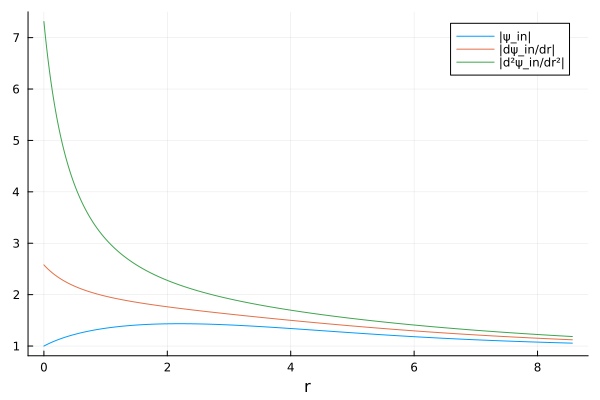

In [14]:
plot(r_values.-rp, abs.(psi_in_values), xlabel="r", label="|ψ_in|")
plot!(r_values.-rp, abs.(dpsi_in_values), xlabel="r", label="|dψ_in/dr|")
plot!(r_values.-rp, abs.(d2psi_in_values), xlabel="r", label="|d²ψ_in/dr²|")

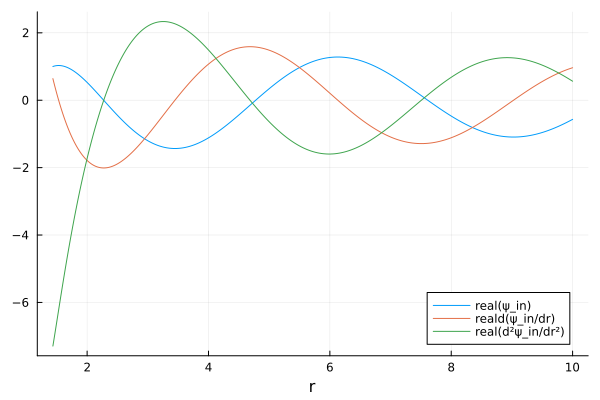

In [15]:
#plot(r_values, real.(psi_up_values), xlabel="r", label="real(ψ_up)")
plot(r_values, real.(psi_in_values), xlabel="r", label="real(ψ_in)")
plot!(r_values, real.(dpsi_in_values), xlabel="r", label="reald(ψ_in/dr)")
plot!(r_values, real.(d2psi_in_values), xlabel="r", label="real(d²ψ_in/dr²)")

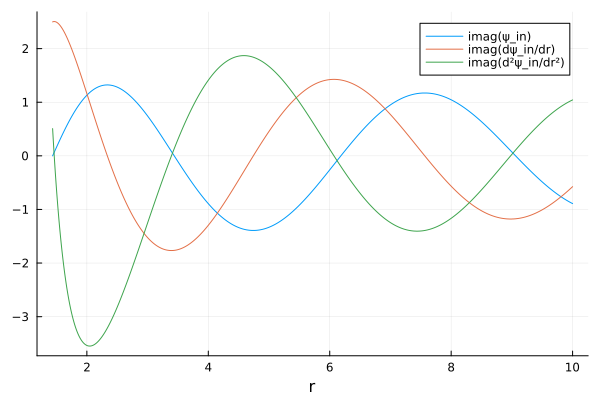

In [16]:
plot(r_values, imag.(psi_in_values), xlabel="r", label="imag(ψ_in)")
plot!(r_values, imag.(dpsi_in_values), xlabel="r", label="imag(dψ_in/dr)")
plot!(r_values, imag.(d2psi_in_values), xlabel="r", label="imag(d²ψ_in/dr²)")